In [2]:
import pandas as pd
from pycaret.regression import *
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.combine import SMOTEENN
import optunahub
import optuna

from sklearn.preprocessing import PowerTransformer

from pycaret.internal.preprocess.transformers import TransformerWrapper

In [2]:
## GK
## ---> >60  = 2
## ---> cs*4
## ---> ((sv)/3)*1
## ---> gc
## ---> yc*-1


## DEF
## ---> >60  = 2
## ---> xg*6
## ---> xa*3
## ---> cs*4
## ---> gc
## ---> yc*-1


## MID
## ---> >60  = +2
## ---> xg*5
## ---> xa*3
## ---> cs*1
## ---> yc*-1


## FWD
## ---> >60  = 2
## ---> xg*4
## ---> xa*3
## ---> yc*-1

In [3]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')
data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] != gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])


In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]



# Goals


## Def


In [5]:
def_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

In [62]:

def_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xg_data = def_data[def_xg_features]
def_xg_data_tar = def_data_tar[def_xg_features]

def_data.reset_index(drop=True, inplace=True)
def_xg_data.reset_index(drop=True, inplace=True)

def_xg_data.drop(columns=['position'], inplace=True)
def_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)


xG
0.000000    4082
0.034354       2
0.084468       2
0.014015       2
0.019109       2
            ... 
0.032757       1
0.115458       1
0.086272       1
0.027934       1
0.405868       1
Name: count, Length: 2351, dtype: int64


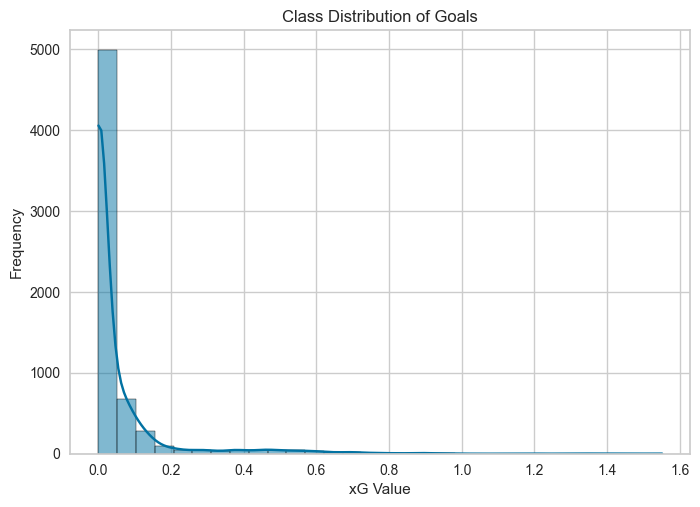

In [64]:
print(def_xg_data['xG'].value_counts())

sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

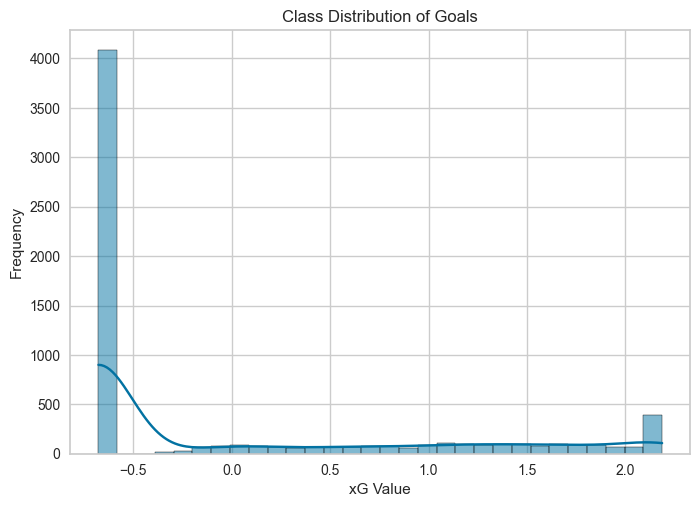

In [ ]:
pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(def_xg_data[['xG']])

def_xg_data['xG'] = pt.transform(def_xg_data[['xG']])


sns.histplot(data=def_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=def_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [66]:
base_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_def_xg_best = base_def_xg_model.compare_models(sort='MAE', n_select=1)
base_def_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003909 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5892
[LightGBM] [Info] Number of data points in the train set: 5164, number of used features: 86
[LightGBM] [Info] Start training from score -0.004189


,Description,Value
0,Session id,773
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6455, 147)"
4,Transformed data shape,"(6455, 30)"
5,Transformed train set shape,"(5164, 30)"
6,Transformed test set shape,"(1291, 30)"
7,Numeric features,145
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3186,0.2921,0.5400,0.7088,0.2448,1.6716,1.8880
rf,Random Forest Regressor,0.3194,0.2952,0.5427,0.7057,0.2440,1.8444,3.7450
lightgbm,Light Gradient Boosting Machine,0.3271,0.3005,0.5477,0.7005,0.2463,1.5677,0.9070
gbr,Gradient Boosting Regressor,0.3367,0.2977,0.5453,0.7031,0.2525,1.5872,1.7060
xgboost,Extreme Gradient Boosting,0.3577,0.3331,0.5767,0.6675,0.2487,1.7188,1.0520
ada,AdaBoost Regressor,0.3685,0.3252,0.5700,0.6756,0.2381,1.8639,0.9230
dt,Decision Tree Regressor,0.3786,0.5464,0.7381,0.4564,0.2683,1.8852,0.7890
huber,Huber Regressor,0.4398,0.5185,0.7196,0.4841,0.3258,1.5874,0.9030
knn,K Neighbors Regressor,0.4471,0.4791,0.6917,0.5225,0.3044,1.6820,0.6100
omp,Orthogonal Matching Pursuit,0.5171,0.4750,0.6888,0.5271,0.3547,1.4925,0.6650


ExtraTreesRegressor(n_jobs=-1, random_state=773)

In [67]:
evaluate_model(base_def_xg_best,)
# plot_model(base_fwd_y_best, plot='confusion_matrix')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

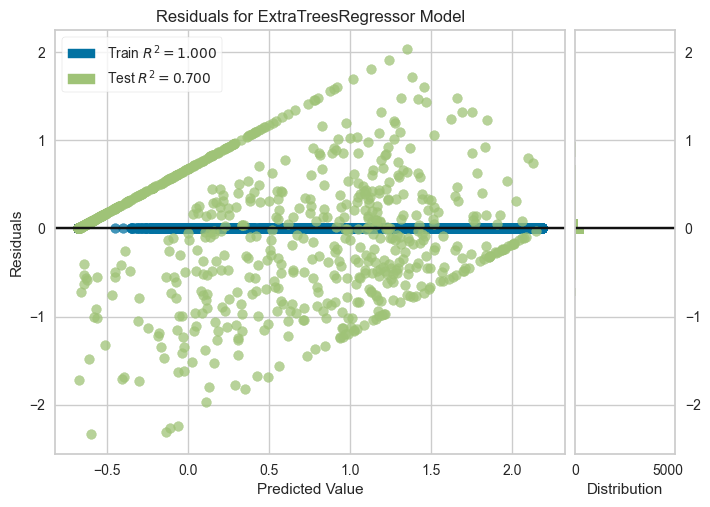

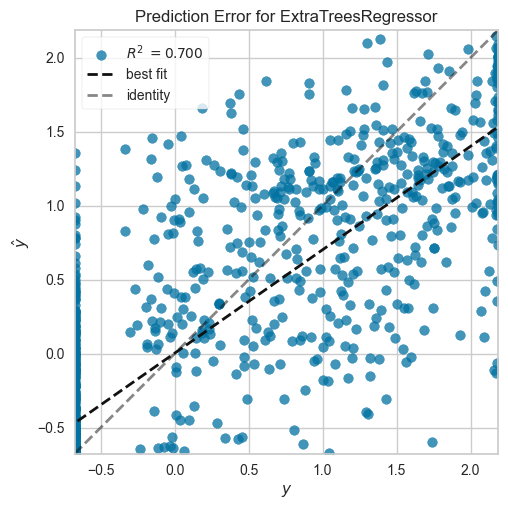

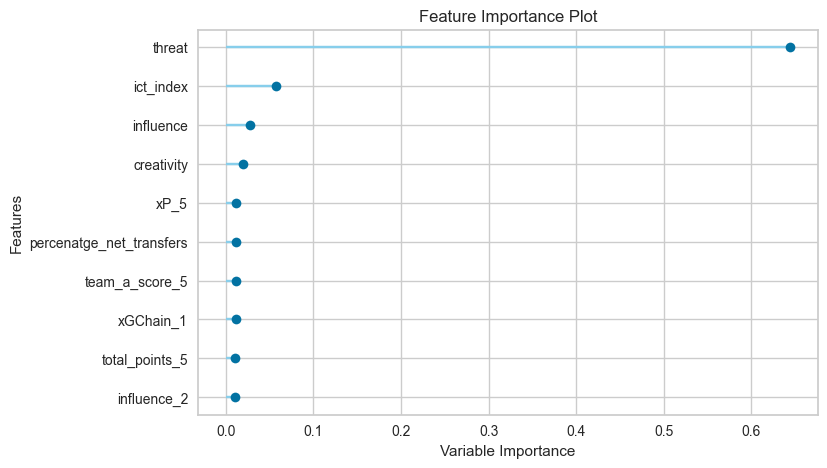

In [68]:
plot_model(base_def_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_def_xg_best, plot='error')          # Prediction error plot
plot_model(base_def_xg_best, plot='feature')        # Feature importance

### Blended Model


In [ ]:
blend_def_xg_model = setup(def_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

def_xg_best = compare_models(n_select=3, sort='MAE')
print(def_xg_best)

print('Blended model')
# Ensemble (blend or stack)
def_xg_blended = blend_models(def_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001767 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5844
[LightGBM] [Info] Number of data points in the train set: 5164, number of used features: 86
[LightGBM] [Info] Start training from score 0.008468


,Description,Value
0,Session id,2563
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6455, 147)"
4,Transformed data shape,"(6455, 30)"
5,Transformed train set shape,"(5164, 30)"
6,Transformed test set shape,"(1291, 30)"
7,Numeric features,145
8,Rows with missing values,6.1%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.3241,0.2981,0.5456,0.7042,0.2468,1.6921,2.1860
rf,Random Forest Regressor,0.3253,0.3026,0.5498,0.6998,0.2459,1.6847,3.8220
lightgbm,Light Gradient Boosting Machine,0.3390,0.3134,0.5593,0.6890,0.2524,1.5932,0.7980
gbr,Gradient Boosting Regressor,0.3440,0.3078,0.5544,0.6944,0.2540,1.6818,1.6960
xgboost,Extreme Gradient Boosting,0.3661,0.3430,0.5852,0.6597,0.2566,1.9496,1.0240
ada,AdaBoost Regressor,0.3791,0.3346,0.5782,0.6681,0.2429,1.5971,0.7930
dt,Decision Tree Regressor,0.3962,0.5879,0.7653,0.4168,0.2690,2.5648,0.9050
huber,Huber Regressor,0.4518,0.5264,0.7250,0.4783,0.3309,1.3400,0.7690
knn,K Neighbors Regressor,0.4680,0.5067,0.7109,0.4970,0.3127,1.8496,0.6840
ridge,Ridge Regression,0.5249,0.4842,0.6955,0.5200,0.3595,1.4095,0.5900


[ExtraTreesRegressor(n_jobs=-1, random_state=2563), RandomForestRegressor(n_jobs=-1, random_state=2563), LGBMRegressor(n_jobs=-1, random_state=2563)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3190,0.2819,0.5310,0.7107,0.2493,2.2129
1,0.3545,0.3238,0.5690,0.6825,0.2439,1.1481
2,0.3164,0.2958,0.5439,0.7239,0.2513,4.7332
3,0.3334,0.3004,0.5481,0.7198,0.2514,1.1532
4,0.3069,0.2814,0.5305,0.6825,0.2574,0.9389
5,0.3052,0.2611,0.5110,0.7403,0.2386,2.1436
6,0.3333,0.3207,0.5663,0.6904,0.2454,0.8224
7,0.3054,0.2709,0.5205,0.7364,0.2348,1.0936
8,0.3486,0.3325,0.5766,0.6726,0.2463,0.8526


### Save Model


In [71]:
# # Patch method to prevent column reordering errors
# def _reorder_cols(self, df, original_df):
#     # Just return df without modifying columns
#     return df

# Apply patch
# TransformerWrapper._reorder_cols = _reorder_cols
def_xg_final_model = finalize_model(base_def_xg_best)
save_model(def_xg_final_model, 'def_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

## Mid


In [72]:
mid_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]

In [74]:

mid_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xg_data = mid_data[mid_xg_features]
mid_xg_data_tar = mid_data_tar[mid_xg_features]

mid_data.reset_index(drop=True, inplace=True)
mid_xg_data.reset_index(drop=True, inplace=True)

mid_xg_data.drop(columns=['position'], inplace=True)
mid_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

xG
0.000000    2380
0.761169      10
0.761169       3
0.025847       2
0.119025       2
            ... 
0.628306       1
0.029697       1
0.581832       1
0.045067       1
0.474898       1
Name: count, Length: 4390, dtype: int64


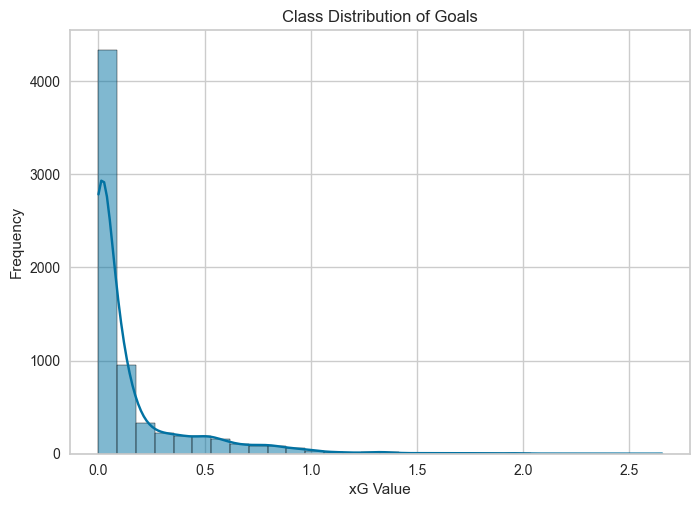

In [75]:
print(mid_xg_data['xG'].value_counts())

sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

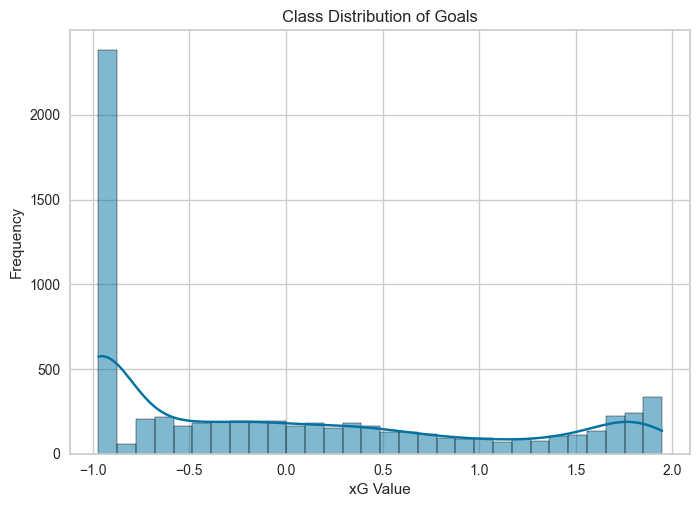

In [76]:
pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(mid_xg_data[['xG']])

mid_xg_data['xG'] = pt.transform(mid_xg_data[['xG']])


sns.histplot(data=mid_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=mid_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

### Base Model


In [77]:
base_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_mid_xg_best = base_mid_xg_model.compare_models(sort='MAE', n_select=1)
base_mid_xg_best

# print('Tuning the model...')
# def_xg_base_tuned = tune_model(base_def_xg_best, search_library='optuna')



[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004429 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7447
[LightGBM] [Info] Number of data points in the train set: 5469, number of used features: 81
[LightGBM] [Info] Start training from score -0.003713


,Description,Value
0,Session id,781
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6837, 147)"
4,Transformed data shape,"(6837, 30)"
5,Transformed train set shape,"(5469, 30)"
6,Transformed test set shape,"(1368, 30)"
7,Numeric features,145
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3663,0.2794,0.5282,0.7161,0.2593,2.6955,6.2840
et,Extra Trees Regressor,0.3703,0.2819,0.5307,0.7136,0.2597,2.6299,2.7060
gbr,Gradient Boosting Regressor,0.3719,0.2749,0.5240,0.7206,0.2567,2.4069,1.9360
lightgbm,Light Gradient Boosting Machine,0.3742,0.2830,0.5315,0.7123,0.2603,2.5244,1.0060
xgboost,Extreme Gradient Boosting,0.3966,0.3105,0.5568,0.6843,0.2671,3.4100,1.0730
ada,AdaBoost Regressor,0.4512,0.3224,0.5675,0.6722,0.2891,2.6688,1.1730
knn,K Neighbors Regressor,0.4619,0.3930,0.6266,0.6009,0.2929,2.8483,1.4930
huber,Huber Regressor,0.4623,0.4070,0.6377,0.5864,0.2895,1.8367,2.2550
lr,Linear Regression,0.4799,0.3818,0.6177,0.6123,0.3024,1.7046,4.0160
ridge,Ridge Regression,0.4800,0.3817,0.6176,0.6124,0.3024,1.7062,1.2370


RandomForestRegressor(n_jobs=-1, random_state=781)

In [78]:
evaluate_model(base_mid_xg_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

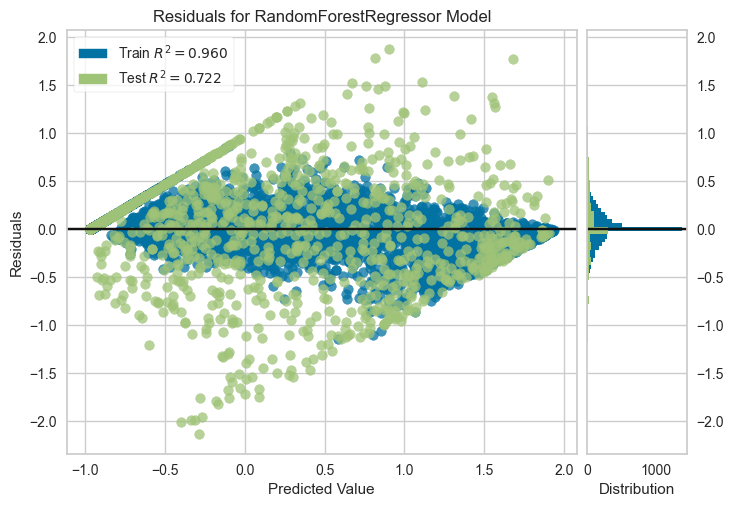

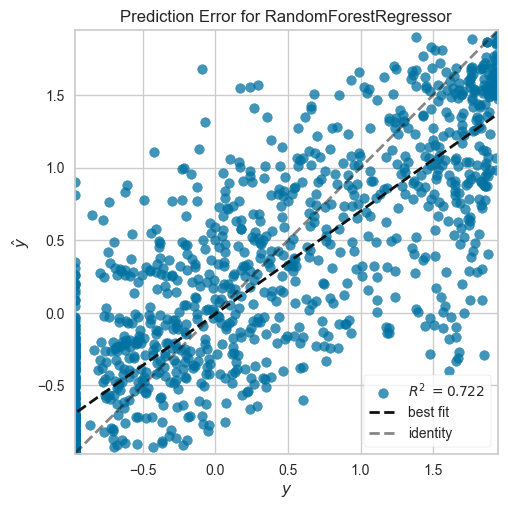

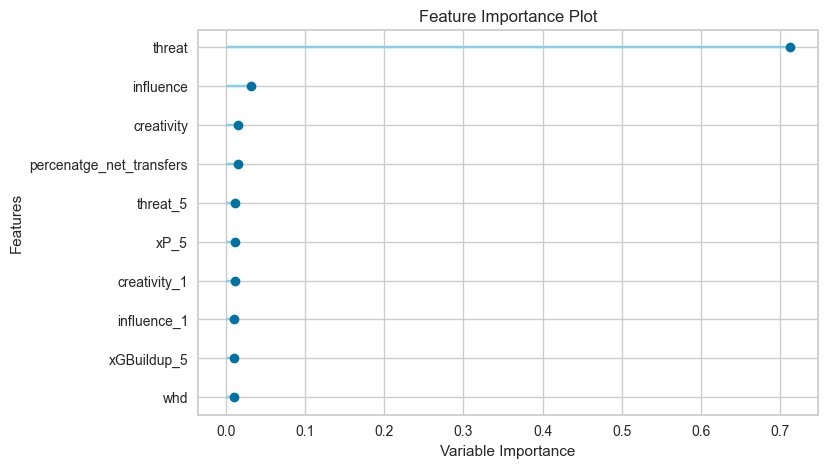

In [79]:
plot_model(base_mid_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_mid_xg_best, plot='error')          # Prediction error plot
plot_model(base_mid_xg_best, plot='feature')        # Feature importance

### Blended Model


In [80]:
blend_mid_xg_model = setup(mid_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

mid_xg_best = compare_models(n_select=3, sort='MAE')
print(mid_xg_best)

print('Blended model')
# Ensemble (blend or stack)
mid_xg_blended = blend_models(mid_xg_best, optimize='MAE')

# fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007774 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7453
[LightGBM] [Info] Number of data points in the train set: 5469, number of used features: 82
[LightGBM] [Info] Start training from score -0.003392


,Description,Value
0,Session id,1529
1,Target,xG
2,Target type,Regression
3,Original data shape,"(6837, 147)"
4,Transformed data shape,"(6837, 30)"
5,Transformed train set shape,"(5469, 30)"
6,Transformed test set shape,"(1368, 30)"
7,Numeric features,145
8,Rows with missing values,6.3%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.3652,0.2822,0.5309,0.7192,0.2598,2.4772,5.2900
et,Extra Trees Regressor,0.3691,0.2808,0.5295,0.7207,0.2585,2.4792,2.5830
gbr,Gradient Boosting Regressor,0.3730,0.2762,0.5252,0.7253,0.2571,2.3746,3.8100
lightgbm,Light Gradient Boosting Machine,0.3733,0.2826,0.5312,0.7189,0.2573,2.7019,1.2020
xgboost,Extreme Gradient Boosting,0.3984,0.3137,0.5599,0.6879,0.2670,2.5953,2.7180
knn,K Neighbors Regressor,0.4604,0.3968,0.6297,0.6055,0.2914,2.5300,0.6710
huber,Huber Regressor,0.4627,0.4125,0.6416,0.5904,0.2900,1.8864,0.8340
ada,AdaBoost Regressor,0.4672,0.3350,0.5785,0.6664,0.2948,2.7122,1.1110
dt,Decision Tree Regressor,0.4811,0.5579,0.7467,0.4445,0.3126,3.6023,0.7920
lr,Linear Regression,0.4825,0.3872,0.6218,0.6155,0.3029,1.7225,1.4120


[RandomForestRegressor(n_jobs=-1, random_state=1529), ExtraTreesRegressor(n_jobs=-1, random_state=1529), GradientBoostingRegressor(random_state=1529)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.3762,0.2902,0.5387,0.7073,0.2589,1.9175
1,0.3833,0.2816,0.5306,0.7075,0.2579,3.9051
2,0.3703,0.2705,0.5201,0.7313,0.2486,1.2048
3,0.3384,0.2287,0.4783,0.7709,0.2529,2.3664
4,0.3452,0.2440,0.4940,0.7506,0.2566,1.9984
5,0.3670,0.2819,0.5309,0.7109,0.2627,1.5691
6,0.3552,0.2662,0.5160,0.7496,0.2536,1.4484
7,0.3591,0.2962,0.5443,0.7154,0.2489,1.9019
8,0.3888,0.2987,0.5466,0.7246,0.2695,6.2803


### Save Model


In [5]:
mid_xg_final_model = finalize_model(mid_xg_blended)
save_model(mid_xg_final_model, 'mid_xg_final_model')

NameError: name 'mid_xg_blended' is not defined

## For


xG
0.000000    283
0.761169      6
0.295594      2
0.080153      2
0.416487      2
           ... 
0.319068      1
1.631009      1
0.619680      1
0.177437      1
0.354086      1
Name: count, Length: 1243, dtype: int64


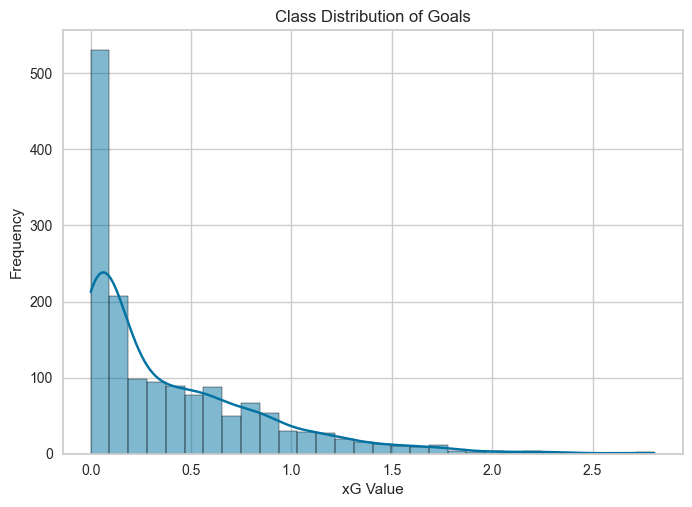

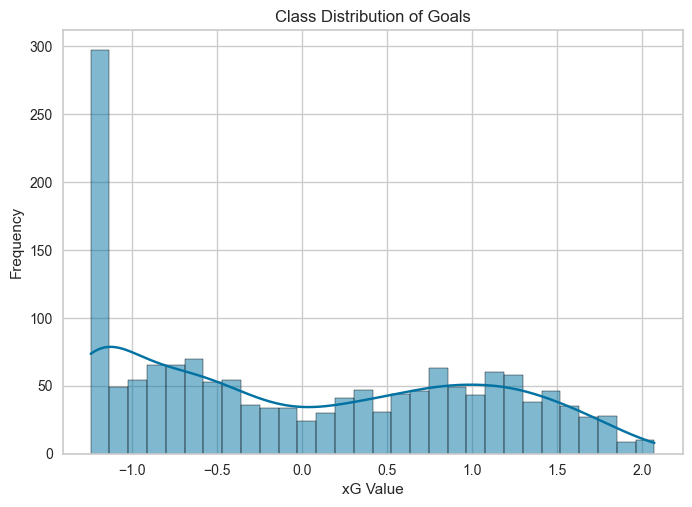

In [7]:
f_xg_features = [ 'position',  'xG', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',


            'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1',  'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2',  'goals_scored_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3',  'goals_scored_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4',  'goals_scored_4', 'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5',  'goals_scored_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]



fwd_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xg_data = fwd_data[f_xg_features]
fwd_xg_data_tar = fwd_data_tar[f_xg_features]

fwd_data.reset_index(drop=True, inplace=True)
fwd_xg_data.reset_index(drop=True, inplace=True)

fwd_xg_data.drop(columns=['position'], inplace=True)
fwd_xg_data_tar.drop(columns=['xG', 'position'], inplace=True)

print(fwd_xg_data['xG'].value_counts())

sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()

pt = PowerTransformer(method='yeo-johnson',  standardize=True)
pt.fit(fwd_xg_data[['xG']])

fwd_xg_data['xG'] = pt.transform(fwd_xg_data[['xG']])


sns.histplot(data=fwd_xg_data, x='xG', bins=30, kde=True) #countplot(x='xG', data=fwd_xg_data)
plt.title('Class Distribution of Goals')
plt.xlabel('xG Value')
plt.ylabel('Frequency')
plt.show()


### Base Model


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002854 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6191
[LightGBM] [Info] Number of data points in the train set: 1232, number of used features: 81
[LightGBM] [Info] Start training from score 0.009768


,Description,Value
0,Session id,805
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1540, 148)"
4,Transformed data shape,"(1540, 30)"
5,Transformed train set shape,"(1232, 30)"
6,Transformed test set shape,"(308, 30)"
7,Numeric features,146
8,Rows with missing values,4.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.4137,0.2950,0.5384,0.6992,0.2636,1.1400,0.7230
rf,Random Forest Regressor,0.4155,0.3037,0.5463,0.6905,0.2652,1.1217,1.4940
et,Extra Trees Regressor,0.4216,0.3132,0.5548,0.6808,0.2700,1.0367,0.9710
lightgbm,Light Gradient Boosting Machine,0.4289,0.3176,0.5591,0.6760,0.2638,1.2255,0.5790
xgboost,Extreme Gradient Boosting,0.4471,0.3461,0.5838,0.6473,0.2720,1.2761,0.8540
lr,Linear Regression,0.4913,0.3660,0.5984,0.6261,0.2880,1.1424,1.9240
ridge,Ridge Regression,0.4917,0.3654,0.5979,0.6266,0.2879,1.1451,0.4280
huber,Huber Regressor,0.4917,0.3961,0.6227,0.5948,0.2790,1.1899,0.4910
br,Bayesian Ridge,0.4932,0.3673,0.5989,0.6246,0.2887,1.1208,0.4210
knn,K Neighbors Regressor,0.4960,0.4139,0.6421,0.5758,0.2798,1.1005,0.4180


GradientBoostingRegressor(random_state=805)
Évaluate the model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

Plots...


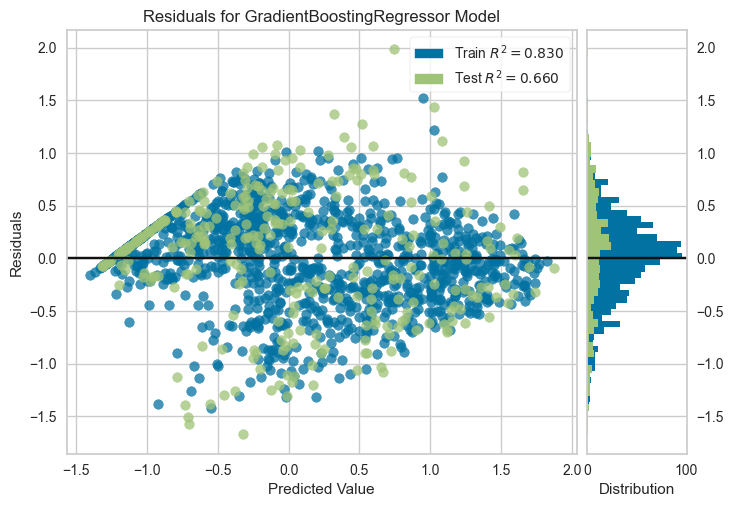

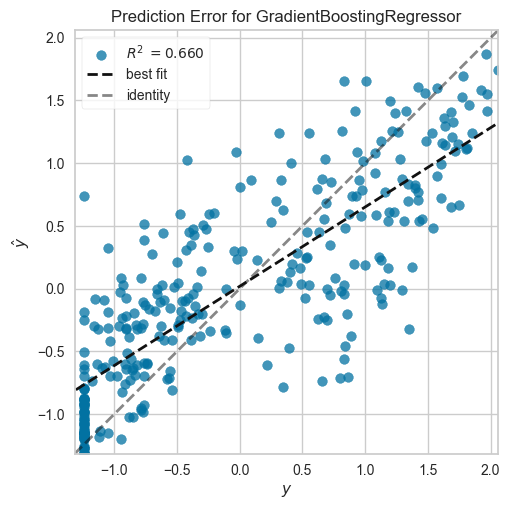

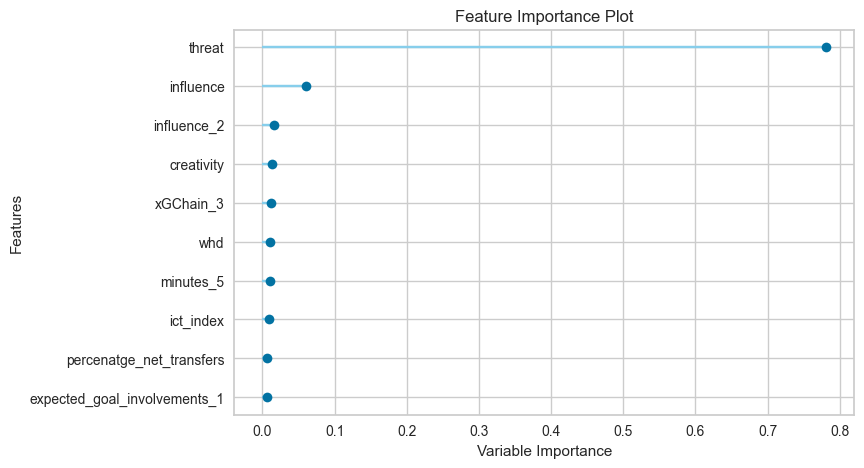

In [14]:
base_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features

                )

base_fwd_xg_best = base_fwd_xg_model.compare_models(sort='MAE', n_select=1)
print(base_fwd_xg_best)

print('Évaluate the model...')
evaluate_model(base_fwd_xg_best)

print('Plots...')
plot_model(base_fwd_xg_best, plot='residuals')      # Residuals vs. predicted values
plot_model(base_fwd_xg_best, plot='error')          # Prediction error plot
plot_model(base_fwd_xg_best, plot='feature')        # Feature importance



### Blended Model


In [10]:
blend_fwd_xg_model = setup(fwd_xg_data, target = 'xG',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                )

fwd_xg_best = compare_models(n_select=3, sort='MAE')
print(fwd_xg_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_xg_blended = blend_models(fwd_xg_best, optimize='MAE')

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5809
[LightGBM] [Info] Number of data points in the train set: 1232, number of used features: 80
[LightGBM] [Info] Start training from score -0.011973


,Description,Value
0,Session id,4188
1,Target,xG
2,Target type,Regression
3,Original data shape,"(1540, 147)"
4,Transformed data shape,"(1540, 30)"
5,Transformed train set shape,"(1232, 30)"
6,Transformed test set shape,"(308, 30)"
7,Numeric features,145
8,Rows with missing values,4.7%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
rf,Random Forest Regressor,0.4342,0.3269,0.5709,0.6687,0.2705,2.0990,1.5620
et,Extra Trees Regressor,0.4376,0.3253,0.5689,0.6702,0.2702,1.9816,1.0140
lightgbm,Light Gradient Boosting Machine,0.4380,0.3358,0.5783,0.6596,0.2688,2.4144,0.7870
gbr,Gradient Boosting Regressor,0.4404,0.3277,0.5712,0.6681,0.2661,1.9939,0.8210
xgboost,Extreme Gradient Boosting,0.4589,0.3622,0.6004,0.6329,0.2700,1.9554,0.6050
knn,K Neighbors Regressor,0.4778,0.3880,0.6202,0.6065,0.2807,2.3283,0.5010
huber,Huber Regressor,0.5012,0.4089,0.6389,0.5855,0.2837,1.5398,0.7540
lr,Linear Regression,0.5033,0.3817,0.6173,0.6132,0.2933,1.6317,2.0430
ridge,Ridge Regression,0.5035,0.3810,0.6167,0.6139,0.2935,1.6394,0.6810
br,Bayesian Ridge,0.5056,0.3831,0.6182,0.6119,0.2916,1.5720,0.6500


[RandomForestRegressor(n_jobs=-1, random_state=4188), ExtraTreesRegressor(n_jobs=-1, random_state=4188), LGBMRegressor(n_jobs=-1, random_state=4188)]
Blended model


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,0.4818,0.3830,0.6189,0.6410,0.2748,0.7177
1,0.3917,0.2654,0.5152,0.7300,0.2491,0.8333
2,0.4412,0.3536,0.5947,0.6512,0.2658,0.9631
3,0.4583,0.3451,0.5875,0.6516,0.2764,0.8085
4,0.3579,0.2701,0.5197,0.7204,0.2238,0.9440
5,0.4526,0.3288,0.5734,0.6855,0.2803,0.8781
6,0.4422,0.3289,0.5735,0.6656,0.2628,0.8476
7,0.4773,0.3582,0.5985,0.6022,0.3111,12.5080
8,0.3963,0.2950,0.5432,0.6798,0.2529,1.6345


### Save Model


In [15]:
fwd_xg_final_model = finalize_model(base_fwd_xg_best)
save_model(fwd_xg_final_model, 'fwd_xg_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'expected_goals_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_1', 'creativi...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('remove_multicollinearity',
 

# Assists


## Def


In [ ]:
def_xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence',
                 'creativity', 'threat','starts',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'shots_2', 'xA_2', 'assists_x_2',
            'assists_y_2',
            'key_passes_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4',  'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'shots_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]


def_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xa_data = def_xa_data[def_xa_features]
def_xa_data_tar = def_xa_data_tar[def_xa_features]

def_xa_data.reset_index(drop=True, inplace=True)
def_xa_data.reset_index(drop=True, inplace=True)

def_xa_data.drop(columns=['position'], inplace=True)
def_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

In [55]:
def_xa_model = setup(def_xa_data, target = 'xA')
def_xa_best = def_xa_model.compare_models()
def_xa_best
def_xa_model.evaluate_model(def_xa_best)

,Description,Value
0,Session id,2179
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6316, 118)"
4,Transformed data shape,"(6316, 118)"
5,Transformed train set shape,"(4421, 118)"
6,Transformed test set shape,"(1895, 118)"
7,Numeric features,116
8,Rows with missing values,4.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
omp,Orthogonal Matching Pursuit,0.0483,0.0103,0.1009,0.4598,0.0762,1.5352,0.0930
br,Bayesian Ridge,0.0483,0.0103,0.1009,0.4598,0.0763,1.5229,0.1580
ridge,Ridge Regression,0.0507,0.0104,0.1016,0.4522,0.0772,1.5204,0.1380
lr,Linear Regression,0.0515,0.0105,0.1021,0.4471,0.0777,1.5236,1.3820
gbr,Gradient Boosting Regressor,0.0431,0.0105,0.1023,0.4448,0.0773,1.5839,2.9050
et,Extra Trees Regressor,0.0433,0.0107,0.1032,0.4355,0.0784,1.8339,3.8080
rf,Random Forest Regressor,0.0431,0.0108,0.1036,0.4310,0.0791,1.8804,6.4260
lightgbm,Light Gradient Boosting Machine,0.0443,0.0109,0.1041,0.4258,0.0791,1.6471,0.7580
xgboost,Extreme Gradient Boosting,0.0458,0.0112,0.1055,0.4113,0.0804,1.6070,0.8340
en,Elastic Net,0.0530,0.0121,0.1097,0.3639,0.0822,1.0725,0.0930


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [32]:
def_xa_model.evaluate_model(def_xa_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [33]:
preds = def_xa_model.predict_model(def_xa_best, data=def_xa_data_tar)

preds.rename(columns={'prediction_label': 'xA_pred'}, inplace=True)

def_xa_preds = preds[['xA_pred']]
def_xa_preds

def_data_tar = pd.concat([def_data_tar, def_xa_preds], axis=1)
def_data_tar

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha,xG_pred,xA_pred
84,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.15,NaN,0.0,-0.391304,NaN,0.615,0.220,0.164,0.058990,0.057305
356,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.50,NaN,0.0,0.581669,NaN,0.732,0.173,0.095,0.048398,0.052691
402,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.23,NaN,0.0,0.791684,NaN,0.732,0.173,0.095,0.014783,0.051283
464,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.28,1.06,0.0,-0.857143,NaN,0.732,0.173,0.095,0.049177,0.058501
531,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.06,NaN,0.0,-0.991079,NaN,0.732,0.173,0.095,0.037493,0.051040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.40,NaN,0.0,-0.284188,NaN,0.624,0.212,0.164,0.050750,0.056092
9566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.09,NaN,0.0,0.739250,NaN,0.615,0.220,0.164,0.051292,0.058739
9684,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.04,NaN,0.0,-0.600945,NaN,0.441,0.263,0.296,0.071043,0.060093
9704,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.02,NaN,0.0,0.053381,NaN,0.615,0.220,0.164,0.060491,0.037845


In [56]:
save_model(def_xa_best, model_name='def_xa_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat', 'starts',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1..._cards_1',
                                              'yellow_cards_1', 'starts_1',
                                              'team_

## Mid


In [83]:
mid_xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'shots_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4',  'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'shots_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]


mid_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_xa_data = mid_xa_data[mid_xa_features]
mid_xa_data_tar = mid_xa_data_tar[mid_xa_features]

mid_xa_data.reset_index(drop=True, inplace=True)
mid_xa_data.reset_index(drop=True, inplace=True)

mid_xa_data.drop(columns=['position'], inplace=True)
mid_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

In [84]:
mid_xa_model = setup(mid_xa_data, target = 'xA')
mid_xa_best = mid_xa_model.compare_models()
mid_xa_best
mid_xa_model.evaluate_model(mid_xa_best)

,Description,Value
0,Session id,2560
1,Target,xA
2,Target type,Regression
3,Original data shape,"(6698, 117)"
4,Transformed data shape,"(6698, 117)"
5,Transformed train set shape,"(4688, 117)"
6,Transformed test set shape,"(2010, 117)"
7,Numeric features,115
8,Rows with missing values,4.3%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.0949,0.0272,0.1645,0.4866,0.1175,1.4054,3.4760
br,Bayesian Ridge,0.1041,0.0280,0.1669,0.4721,0.1192,1.4888,0.0980
omp,Orthogonal Matching Pursuit,0.1041,0.0280,0.1669,0.4720,0.1192,1.4910,0.0770
ridge,Ridge Regression,0.1065,0.0281,0.1673,0.4690,0.1201,1.5042,0.0690
et,Extra Trees Regressor,0.0978,0.0281,0.1672,0.4684,0.1201,1.6072,6.0970
lr,Linear Regression,0.1073,0.0283,0.1677,0.4662,0.1206,1.5071,1.3260
rf,Random Forest Regressor,0.0959,0.0283,0.1678,0.4661,0.1205,1.6035,13.5510
lightgbm,Light Gradient Boosting Machine,0.0963,0.0283,0.1678,0.4652,0.1201,1.4214,0.8680
en,Elastic Net,0.1046,0.0294,0.1709,0.4472,0.1212,1.4854,0.0860
xgboost,Extreme Gradient Boosting,0.1058,0.0316,0.1774,0.4020,0.1282,1.5239,1.2970


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [85]:
preds = mid_xa_model.predict_model(mid_xa_best, data=mid_xa_data_tar)

preds.rename(columns={'prediction_label': 'xA_pred'}, inplace=True)

mid_xa_preds = preds[['xA_pred']]
mid_xa_preds

mid_data_tar = pd.concat([mid_data_tar, mid_xa_preds], axis=1)
mid_data_tar

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,xGChain_5,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha,xA_pred
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.50,0.30,2.02,0.0,-0.375000,NaN,0.615,0.220,0.164,0.107377
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.20,0.14,NaN,0.0,-0.305057,NaN,0.615,0.220,0.164,0.120347
141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.26,0.02,NaN,0.0,-0.909705,NaN,0.615,0.220,0.164,0.125533
229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.11,0.11,NaN,0.0,-0.109684,NaN,0.615,0.220,0.164,0.106982
282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.57,0.45,NaN,0.0,-0.103448,NaN,0.732,0.173,0.095,0.110549
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9770,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.12,0.01,NaN,0.0,-0.762236,NaN,0.615,0.220,0.164,0.116197
9797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.65,0.10,NaN,0.0,0.063236,NaN,0.615,0.220,0.164,0.136772
9863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.07,0.05,NaN,0.0,-0.759494,NaN,0.615,0.220,0.164,0.101517
9927,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.13,0.12,NaN,0.0,-0.600000,NaN,0.615,0.220,0.164,0.115156


In [86]:
save_model(mid_xa_best, model_name='mid_xa_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1', 'red_ca...
                                              'yellow_cards_1', 'starts_1',
                                              'team_a_score_1'

## For


In [94]:
f_xa_features = [ 'position',  'xA', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat',

            'expected_assists_1', 'expected_goal_involvements_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1',
            'red_cards_1', 'yellow_cards_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1',  'shots_1','xA_1', 'assists_x_1', 'assists_y_1',
            'key_passes_1', 'xGChain_1', 'xGBuildup_1',  'xP_1',

            'expected_assists_2', 'expected_goal_involvements_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2',
            'red_cards_2', 'yellow_cards_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'shots_2', 'xA_2', 'assists_x_2', 'assists_y_2',
            'key_passes_2', 'xGChain_2', 'xGBuildup_2',  'xP_2',

            'expected_assists_3', 'expected_goal_involvements_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3',
            'red_cards_3', 'yellow_cards_3', 'starts_3', 'team_a_score_3', 'team_h_score_3', 'total_points_3', 'shots_3', 'xA_3', 'assists_x_3', 'assists_y_3',
            'key_passes_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'expected_assists_4', 'expected_goal_involvements_4',  'ict_index_4', 'influence_4', 'creativity_4', 'threat_4', 'minutes_4',
            'red_cards_4', 'yellow_cards_4', 'starts_4', 'team_a_score_4', 'team_h_score_4', 'total_points_4', 'shots_4', 'xA_4', 'assists_x_4', 'assists_y_4',
            'key_passes_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'expected_assists_5', 'expected_goal_involvements_5', 'ict_index_5', 'influence_5', 'creativity_5', 'threat_5', 'minutes_5',
            'red_cards_5', 'yellow_cards_5', 'starts_5', 'team_a_score_5', 'team_h_score_5', 'total_points_5', 'shots_5',  'xA_5', 'assists_x_5', 'assists_y_5',
            'key_passes_5', 'xGChain_5', 'xGBuildup_5',  'xP_5'
]


fwd_xa_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_xa_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_xa_data = fwd_xa_data[f_xa_features]
fwd_xa_data_tar = fwd_xa_data_tar[f_xa_features]

fwd_xa_data.reset_index(drop=True, inplace=True)
fwd_xa_data.reset_index(drop=True, inplace=True)

fwd_xa_data.drop(columns=['position'], inplace=True)
fwd_xa_data_tar.drop(columns=['xA', 'position'], inplace=True)

In [95]:
fwd_xa_model = setup(fwd_xa_data, target = 'xA')
fwd_xa_best = fwd_xa_model.compare_models()
fwd_xa_best
fwd_xa_model.evaluate_model(fwd_xa_best)

,Description,Value
0,Session id,8531
1,Target,xA
2,Target type,Regression
3,Original data shape,"(1519, 117)"
4,Transformed data shape,"(1519, 117)"
5,Transformed train set shape,"(1063, 117)"
6,Transformed test set shape,"(456, 117)"
7,Numeric features,115
8,Rows with missing values,3.4%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
omp,Orthogonal Matching Pursuit,0.0846,0.0200,0.1397,0.4114,0.1047,1.4425,0.0610
br,Bayesian Ridge,0.0844,0.0200,0.1397,0.4108,0.1046,1.4187,0.1090
et,Extra Trees Regressor,0.0799,0.0208,0.1426,0.3791,0.1072,1.6207,1.2810
lightgbm,Light Gradient Boosting Machine,0.0833,0.0213,0.1443,0.3726,0.1086,1.4548,1.5300
en,Elastic Net,0.0907,0.0220,0.1461,0.3657,0.1091,1.2723,0.0810
ridge,Ridge Regression,0.0932,0.0215,0.1451,0.3618,0.1095,1.4210,0.0950
rf,Random Forest Regressor,0.0794,0.0216,0.1453,0.3577,0.1093,1.6521,2.3750
gbr,Gradient Boosting Regressor,0.0834,0.0221,0.1469,0.3434,0.1098,1.4158,2.0230
huber,Huber Regressor,0.0797,0.0229,0.1491,0.3381,0.1092,0.9465,0.2570
lr,Linear Regression,0.0968,0.0224,0.1483,0.3326,0.1128,1.4446,1.4920


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [39]:
preds = fwd_xa_model.predict_model(fwd_xa_best, data=fwd_xa_data_tar)

preds.rename(columns={'prediction_label': 'xA_pred'}, inplace=True)

fwd_xa_preds = preds[['xA_pred']]
fwd_xa_preds

fwd_data_tar = pd.concat([fwd_data_tar, fwd_xa_preds], axis=1)
fwd_data_tar

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha,xG_pred,xA_pred
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.30,2.02,0.0,-0.375000,NaN,0.615,0.220,0.164,0.080359,NaN
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.14,NaN,0.0,-0.305057,NaN,0.615,0.220,0.164,0.072392,NaN
141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.02,NaN,0.0,-0.909705,NaN,0.615,0.220,0.164,0.109488,NaN
229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.11,NaN,0.0,-0.109684,NaN,0.615,0.220,0.164,0.081126,NaN
282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.45,NaN,0.0,-0.103448,NaN,0.732,0.173,0.095,0.065403,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.162303
8042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.208567
8566,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.166596
9431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.166009


In [96]:
save_model(fwd_xa_best, model_name='fwd_xa_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'expected_assists_1',
                                              'expected_goal_involvements_1',
                                              'ict_index_1', 'influence_1',
                                              'creativity_1', 'threat_1',
                                              'minutes_1', 'red_ca...
                                              'yellow_cards_1', 'starts_1',
                                              'team_a_score_1'

# Saves


## GK


In [97]:
g_saves_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

            'saves',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



g_saves_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_saves_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_saves_data = g_saves_data[g_saves_features]
g_saves_data_tar = g_saves_data_tar[g_saves_features]

g_saves_data.reset_index(drop=True, inplace=True)
g_saves_data.reset_index(drop=True, inplace=True)

g_saves_data.drop(columns=['position'], inplace=True)
g_saves_data_tar.drop(columns=['position', 'saves'], inplace=True)

g_saves_model = setup(g_saves_data, target = 'saves')
g_saves_best = g_saves_model.compare_models()
g_saves_best

,Description,Value
0,Session id,7361
1,Target,saves
2,Target type,Regression
3,Original data shape,"(1539, 116)"
4,Transformed data shape,"(1539, 116)"
5,Transformed train set shape,"(1077, 116)"
6,Transformed test set shape,"(462, 116)"
7,Numeric features,114
8,Rows with missing values,4.5%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
br,Bayesian Ridge,0.5257,0.5369,0.7282,0.8605,0.2273,0.2142,0.0730
ridge,Ridge Regression,0.5353,0.5476,0.7355,0.8578,0.2275,0.2211,0.0600
gbr,Gradient Boosting Regressor,0.5329,0.5546,0.7404,0.8566,0.2154,0.2072,1.3200
omp,Orthogonal Matching Pursuit,0.5320,0.5524,0.7388,0.8565,0.2316,0.2169,0.1090
huber,Huber Regressor,0.5274,0.5535,0.7391,0.8560,0.2231,0.2163,0.4130
rf,Random Forest Regressor,0.5384,0.5639,0.7460,0.8542,0.2152,0.2084,2.1870
en,Elastic Net,0.5355,0.5604,0.7438,0.8541,0.2339,0.2180,0.0810
lasso,Lasso Regression,0.5419,0.5637,0.7461,0.8532,0.2354,0.2194,0.0660
et,Extra Trees Regressor,0.5449,0.5681,0.7491,0.8532,0.2113,0.2126,1.5410
llar,Lasso Least Angle Regression,0.5419,0.5637,0.7461,0.8532,0.2354,0.2194,0.0530


BayesianRidge()

In [41]:
preds = g_saves_model.predict_model(g_saves_best, data=g_saves_data_tar)

preds.rename(columns={'prediction_label': 'xA_pred'}, inplace=True)

g_saves_preds = preds[['xA_pred']]
g_saves_preds

fwd_data_tar = pd.concat([fwd_data_tar, g_saves_preds], axis=1)
fwd_data_tar

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha,xG_pred,xA_pred,xA_pred
12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.02,0.0,-0.375000,NaN,0.615,0.220,0.164,0.080359,NaN,NaN
49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,-0.305057,NaN,0.615,0.220,0.164,0.072392,NaN,NaN
141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,-0.909705,NaN,0.615,0.220,0.164,0.109488,NaN,NaN
229,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,-0.109684,NaN,0.615,0.220,0.164,0.081126,NaN,NaN
282,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.0,-0.103448,NaN,0.732,0.173,0.095,0.065403,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.063735
8077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.061898
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.975925
9653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.182116


In [98]:
save_model(g_saves_best, model_name='gk_saves_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1',
                                              'influence_...,
                                              'threat_1', 'minutes_1',
                     

# Goals Conceded


## GK


In [99]:
g_xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

g_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_xgc_data = g_xgc_data[g_xgc_features]
g_xgc_data_tar = g_xgc_data_tar[g_xgc_features]

g_xgc_data.reset_index(drop=True, inplace=True)
g_xgc_data.reset_index(drop=True, inplace=True)

g_xgc_data.drop(columns=['position'], inplace=True)
g_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

g_xgc_model = setup(g_xgc_data, target = 'expected_goals_conceded')
g_xgc_best = g_xgc_model.compare_models()
g_xgc_best

,Description,Value
0,Session id,2963
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(1539, 108)"
4,Transformed data shape,"(1539, 108)"
5,Transformed train set shape,"(1077, 108)"
6,Transformed test set shape,"(462, 108)"
7,Numeric features,106
8,Rows with missing values,4.5%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
gbr,Gradient Boosting Regressor,0.5750,0.5340,0.7289,0.1999,0.2938,0.7327,1.5530
et,Extra Trees Regressor,0.5786,0.5381,0.7322,0.1907,0.2972,0.7461,2.2410
br,Bayesian Ridge,0.5860,0.5464,0.7378,0.1791,0.2982,0.7398,0.0620
omp,Orthogonal Matching Pursuit,0.5909,0.5543,0.7431,0.1665,0.3010,0.7350,0.1320
rf,Random Forest Regressor,0.5926,0.5538,0.7428,0.1658,0.3014,0.7747,2.3440
en,Elastic Net,0.5943,0.5564,0.7445,0.1653,0.3014,0.7682,0.0360
lasso,Lasso Regression,0.5963,0.5621,0.7482,0.1581,0.3034,0.7860,0.0490
llar,Lasso Least Angle Regression,0.5963,0.5621,0.7482,0.1581,0.3034,0.7860,0.0790
huber,Huber Regressor,0.5921,0.5613,0.7479,0.1566,0.2997,0.7290,0.0910
ridge,Ridge Regression,0.5951,0.5681,0.7530,0.1411,0.3050,0.7295,0.1260


GradientBoostingRegressor(random_state=2963)

In [43]:
preds = g_xgc_model.predict_model(g_xgc_best, data=g_xgc_data_tar)

preds.rename(columns={'prediction_label': 'xgc_pred'}, inplace=True)

g_xgc_preds = preds[['xgc_pred']]
g_xgc_preds

g_data_tar = pd.concat([g_xgc_data_tar, g_xgc_preds], axis=1)
g_data_tar

,whh,whd,wha,was_home,ownership_change,percenatge_net_transfers,ict_index,influence,creativity,threat,...,yellow_cards_5,saves_5,starts_5,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,xgc_pred
631,0.187,0.216,0.596,True,0.0,-0.243328,NaN,NaN,NaN,NaN,...,0.0,3.6,1.0,1.0,2.4,1.8,0.10,0.10,NaN,1.521625
719,0.732,0.173,0.095,True,0.0,0.136709,NaN,NaN,NaN,NaN,...,0.2,1.6,1.0,1.6,1.6,1.4,0.11,0.11,NaN,1.383917
811,0.615,0.220,0.164,True,0.0,0.361856,NaN,NaN,NaN,NaN,...,0.0,2.4,1.0,0.6,1.0,3.8,0.13,0.13,NaN,1.383946
837,0.441,0.263,0.296,True,0.0,-0.758231,NaN,NaN,NaN,NaN,...,0.0,1.6,1.0,1.8,1.6,1.0,0.02,0.02,NaN,1.397248
1331,0.695,0.188,0.117,True,0.0,0.514311,NaN,NaN,NaN,NaN,...,0.0,2.8,1.0,0.2,1.2,5.2,0.05,0.05,NaN,1.328719
1680,0.624,0.212,0.164,False,0.0,0.042998,NaN,NaN,NaN,NaN,...,0.0,2.6,1.0,1.0,1.6,4.6,0.08,0.06,NaN,1.381881
1715,0.413,0.271,0.316,True,0.0,-0.193798,NaN,NaN,NaN,NaN,...,0.0,3.0,1.0,1.8,2.4,1.4,0.19,0.19,1.02,1.604890
2298,0.449,0.290,0.262,False,0.0,-0.696991,NaN,NaN,NaN,NaN,...,0.0,3.0,1.0,0.8,1.0,2.6,0.02,0.02,NaN,1.484005
2596,0.441,0.263,0.296,False,0.0,-0.149796,NaN,NaN,NaN,NaN,...,0.2,3.4,1.0,1.2,2.0,4.0,0.18,0.18,NaN,1.486844
3185,0.695,0.188,0.117,False,0.0,-0.550388,NaN,NaN,NaN,NaN,...,0.0,2.8,1.0,2.2,1.6,2.4,0.04,0.03,0.98,1.604397


In [100]:
save_model(g_xgc_best, model_name='gk_xgc_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                              'own_goals_1', 'penalties_saved_1',
                                              'yellow_car

## Def


In [71]:
def_xgc_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',

            'expected_goals_conceded',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3',  'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_xgc_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_xgc_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_xgc_data = def_xgc_data[def_xgc_features]
def_xgc_data_tar = def_xgc_data_tar[def_xgc_features]

def_xgc_data.reset_index(drop=True, inplace=True)
def_xgc_data.reset_index(drop=True, inplace=True)

def_xgc_data.drop(columns=['position'], inplace=True)
def_xgc_data_tar.drop(columns=['position', 'expected_goals_conceded'], inplace=True)

def_xgc_model = setup(def_xgc_data, target = 'expected_goals_conceded')
def_xgc_best = def_xgc_model.compare_models()
def_xgc_best

,Description,Value
0,Session id,1076
1,Target,expected_goals_conceded
2,Target type,Regression
3,Original data shape,"(6316, 108)"
4,Transformed data shape,"(6316, 108)"
5,Transformed train set shape,"(4421, 108)"
6,Transformed test set shape,"(1895, 108)"
7,Numeric features,106
8,Rows with missing values,4.0%
9,Preprocess,True


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,0.5149,0.4842,0.6933,0.3851,0.2899,1.1418,6.6840
lightgbm,Light Gradient Boosting Machine,0.5683,0.5582,0.7455,0.2881,0.3090,1.1488,0.7530
rf,Random Forest Regressor,0.5880,0.5955,0.7701,0.2409,0.3223,1.2821,12.6910
gbr,Gradient Boosting Regressor,0.5909,0.5982,0.7720,0.2369,0.3198,1.2474,3.7340
xgboost,Extreme Gradient Boosting,0.5915,0.6145,0.7822,0.2157,0.3269,1.2345,1.2730
ridge,Ridge Regression,0.6403,0.6859,0.8269,0.1242,0.3497,1.4875,0.0710
lr,Linear Regression,0.6555,0.7255,0.8494,0.0746,0.3592,1.5094,1.0760
omp,Orthogonal Matching Pursuit,0.6709,0.7411,0.8594,0.0540,0.3609,1.5285,0.0720
en,Elastic Net,0.6804,0.7580,0.8691,0.0329,0.3662,1.6171,0.0940
llar,Lasso Least Angle Regression,0.6844,0.7670,0.8743,0.0214,0.3692,1.6589,0.0800


ExtraTreesRegressor(n_jobs=-1, random_state=1076)

In [72]:
preds = def_xgc_model.predict_model(def_xgc_best, data=def_xgc_data_tar)

preds.rename(columns={'prediction_label': 'xgc_pred'}, inplace=True)

def_xgc_preds = preds[['xgc_pred']]
def_xgc_preds

def_data_tar = pd.concat([def_xgc_data_tar, g_xgc_preds], axis=1)
def_data_tar

,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,yellow_cards_5,saves_5,starts_5,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,xgc_pred
84,0.615,0.220,0.164,False,2.0,4.0,0.0,-0.391304,NaN,NaN,...,0.0,0.0,1.0,1.8,0.8,2.6,0.18,0.15,NaN,NaN
356,0.732,0.173,0.095,True,2.0,3.0,0.0,0.581669,NaN,NaN,...,0.0,0.0,1.0,1.6,2.0,0.8,0.50,0.50,NaN,NaN
402,0.732,0.173,0.095,True,2.0,3.0,0.0,0.791684,NaN,NaN,...,0.0,0.0,1.0,1.6,1.6,2.6,0.23,0.23,NaN,NaN
464,0.732,0.173,0.095,True,2.0,3.0,0.0,-0.857143,NaN,NaN,...,0.2,0.0,0.8,1.4,1.8,1.2,0.31,0.28,1.06,NaN
531,0.732,0.173,0.095,True,2.0,3.0,0.0,-0.991079,NaN,NaN,...,0.0,0.0,1.0,1.0,3.0,3.8,0.17,0.06,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7797,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.562051
8077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.387305
9468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.544297
9653,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.653526


In [73]:

save_model(def_xgc_best, model_name='def_xgc_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1', 'ict_index_1',
                                              'influence_1', 'creativity_1'...
                                              'own_goals_1', 'penalties_saved_1',
                                              'yellow_car